In [2]:
pip install torch torchvision

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 3.7 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.5/74.5 MB 6.5 MB/s eta 0:00:0000:0100:01
  Attempting uninstall: torch
    Found existing installation: torch 2.7.1
    Uninstalling torch-2.7.1:
      Successfully uninstalled torch-2.7.1
Note: you may need to restart the kernel to use updated packages.


Epoch 1/3, Loss: 0.1985
Epoch 2/3, Loss: 0.0530
Epoch 3/3, Loss: 0.0600

Test Accuracy: 97.84%

=== Sample Predictions ===


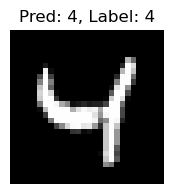

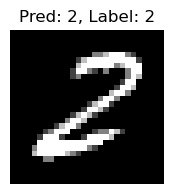

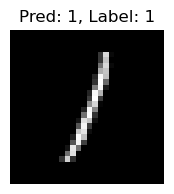

In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

# 1. 데이터 불러오기 (flatten된 형태로)
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x.view(-1))  # 28x28 -> 784 flatten
])

trainset = torchvision.datasets.MNIST(root='./data', train=True,
                                      download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True)

testset = torchvision.datasets.MNIST(root='./data', train=False,
                                     download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=1000, shuffle=False)

# 2. MLP 모델 정의
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(784, 256)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)
        return x

model = MLP()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 3. 학습
epochs = 3
for epoch in range(epochs):
    for images, labels in trainloader:
        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item():.4f}")


# -------------------------------------------------------
# 4. 테스트 정확도 계산
# -------------------------------------------------------
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in testloader:
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"\nTest Accuracy: {100 * correct / total:.2f}%\n")


# -------------------------------------------------------
# 5. 이미지 3장을 직접 보여주고 예측 비교
# -------------------------------------------------------
import random
import numpy as np

# 원본 이미지 (flatten되어 있으므로 reshape 필요)
def show_image(flat_tensor):
    img = flat_tensor.view(28, 28).cpu().numpy()
    plt.imshow(img, cmap='gray')
    plt.axis('off')

# 테스트 셋에서 3개 랜덤 선택
test_iter = iter(testloader)
test_images, test_labels = next(test_iter)

indices = random.sample(range(len(test_images)), 3)

print("=== Sample Predictions ===")

for idx in indices:
    img = test_images[idx].unsqueeze(0)  # (1, 784)
    label = test_labels[idx].item()

    output = model(img)
    pred = torch.argmax(output).item()

    plt.figure(figsize=(2, 2))
    show_image(test_images[idx])
    plt.title(f"Pred: {pred}, Label: {label}")
    plt.show()


# 데이터셋에서 특정 이미지 인덱스를 선택해 보여주는 함수

In [10]:
# -------------------------------------------------------
# MNIST 테스트셋에서 특정 이미지 시각화
# -------------------------------------------------------
def show_dataset_image(index):
    img = testset[index][0]    # flatten된 784 tensor
    label = testset[index][1]  # 정답 라벨

    # flatten → 28x28 reshape
    img_2d = img.view(28, 28)

    plt.imshow(img_2d, cmap='gray')
    plt.title(f"Index: {index}, Label: {label}")
    plt.axis('off')
    plt.show()


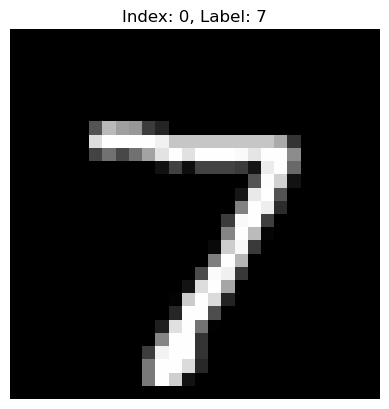

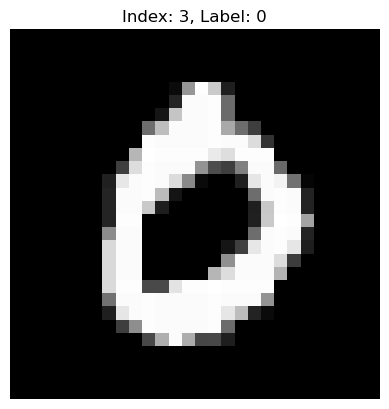

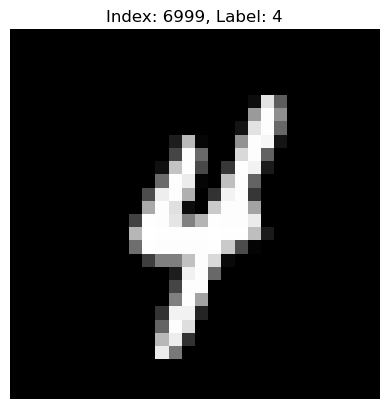

In [27]:
show_dataset_image(0)
show_dataset_image(3)
show_dataset_image(6999)
# 총 70000장임

# 특정 이미지의 픽셀 값을 출력하는 함수

In [16]:
def show_pixel_values(index):
    img_tensor, label = testset[index]

    print(f"=== Index {index} / Label: {label} ===")
    print("Flatten shape:", img_tensor.shape)

    # 784 → 28x28 복원
    img_2d = img_tensor.view(28, 28)

    print("Pixel values (0~1):")
    print(img_2d)


In [17]:
show_pixel_values(0)
show_pixel_values(6999)


=== Index 0 / Label: 7 ===
Flatten shape: torch.Size([784])
Pixel values (0~1):
tensor([[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,

# 이미지 파일을 불러서 flatten하고 값을 출력하는 코드

In [21]:
def flatten_dataset_image(index):
    img_tensor, label = testset[index]   # (784,) 텐서 + 정답

    print(f"=== Index {index} / Label: {label} ===")
    print("Flatten shape:", img_tensor.shape)  # (784,)

    # 784개 값 출력
    flat = img_tensor.view(-1)
    print("\nFlattened pixel values (0~1):")
    print(flat)

    return flat

In [23]:
flatten_dataset_image(0)

=== Index 0 / Label: 7 ===
Flatten shape: torch.Size([784])

Flattened pixel values (0~1):
tensor([0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.000

tensor([0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 

- 이 순서를 부꿔서 입력값을로 주면 당연히 정답 틀리지

# 직접 이미지 파일을 넣어 테스트하고싶은경우

In [8]:
from PIL import Image
import torchvision.transforms.functional as TF

def predict_from_image_file(path):
    # 이미지 로드
    img = Image.open(path).convert('L')   # 흑백 변환
    img = img.resize((28, 28))            # MNIST 크기 맞추기

    # 텐서로 변환 + flatten
    img_tensor = TF.to_tensor(img).view(1, -1)

    pred = predict_single_image(model, img_tensor)
    plt.imshow(img, cmap='gray')
    plt.title(f"Pred: {pred}")
    plt.axis('off')
    plt.show()

    return pred


In [4]:
import random

model.eval()

# 테스트 이미지 1장을 가져오기
test_iter = iter(testloader)
images, labels = next(test_iter)
img = images[0].unsqueeze(0)  # (1,784)
label = labels[0]

# 1) 정상 입력 출력
output1 = model(img)
pred1 = torch.argmax(output1).item()

# 2) 픽셀 순서를 뒤섞기
perm = torch.randperm(784)
shuffled_img = img[:, perm]

output2 = model(shuffled_img)
pred2 = torch.argmax(output2).item()

print(f"정상 입력 예측: {pred1}")
print(f"순서 섞은 입력 예측: {pred2}")
print("정답(label):", label.item())


정상 입력 예측: 7
순서 섞은 입력 예측: 5
정답(label): 7


In [ ]:
# 이미지 픽셀을 입력값으로하는데 이 순서를 바꿔 입력하면 당연히 출력 결과가 다르다
'''
결론은 이지들을 동일하게 섞은후 학습시켰을때 섞인 상태로도 분류가 된다는것이다. 중요한건 모두랜덤하게 섞이는게 아니라 처음부터 동일한 랜덤으로 섞인후 학습
'''